<a href="https://colab.research.google.com/github/dgbeijersbergen/biosensor_model/blob/master/biosensor_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biosensor Optimization — Figure 6 Flowchart
**Beijersbergen & Charmet (2026)** — *Sample volume as a key design parameter in affinity-based biosensors*

Enter your parameters in **Step 1**, then run all cells.

In [145]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ============================================================
# STEP 1 — INPUT PARAMETERS
# All SI units: m, s, mol/m³
# ============================================================

# --- Geometry ---
W_c = 200e-6        # channel width [m]
H_c = 20e-6         # channel height [m]
W_s = 200e-6        # sensor width [m]
L_s = 3e-3          # sensor length [m]

# --- Molecular ---
D     = 8.5e-11     # diffusion coefficient [m²/s]
k_on  = 2.54e2      # association rate [m³/(mol·s)]  (divide M⁻¹s⁻¹ by 1000)
k_off = 4.45e-3     # dissociation rate [1/s]
b_m   = 1.5e-7      # max surface density [mol/m²]

# --- Sample ---
c_in  = 100e-6     # input concentration [mol/m³]  (nM = 1e-6 mol/m³)
Q     = 0.1 * 1e-9/60   # flow rate [m³/s]  (µL/min × 1e-9/60)

The biosensor can be characterized following step 1 from Figure 6.





In [146]:
# ============================================================
# STEP 1 — CHARACTERIZE SYSTEM  (Table in Fig. 6)
# ============================================================

lam   = L_s / H_c                                   # λ = Ls/Hc

Q_c   = 1.79 * lam * W_c * D                        # critical flow rate [m³/s]

# mass transport coefficient km
if Q <= Q_c:
    k_m = Q / (W_c * H_c)                           # complete delivery
else:
    k_m = (D/H_c) * (1.79*lam)**(2/3) * (Q/(D*W_c))**(1/3)  # outside CD

Da    = (k_on * b_m * L_s) / (k_m * H_c)            # Damköhler number
Da_c  = (k_on * b_m * H_c) / (1.79 * D)             # critical Damköhler
t_R   = 1.0 / (k_on * c_in + k_off)                 # reaction timescale [s]
V_min = W_s * L_s * k_on * b_m * t_R                # minimum volume [m³]

b_eq  = (k_on * c_in * b_m) / (k_on * c_in + k_off)
delta = H_c if Q <= Q_c else (L_s * D / (k_m*H_c))              # depletion layer height
eps   = (b_eq * W_s) / (delta * W_c * c_in)         # ε validity parameter

# recompute values if epsilon not valid (system behaves like inside CD)
if eps < 10:
  k_m = Q / (W_c * H_c)                           # complete delivery
  Da    = (k_on * b_m * L_s) / (k_m * H_c)            # Damköhler number

print("Step 1 — System characterization")
print("-" * 42)
print(f"  Qc       = {Q_c*1e9*60:.3f} µL/min")
print(f"  Q        = {Q*1e9*60:.3f} µL/min")
print(f"  k_m       = {k_m:.3e} m/s")
print(f"  Da       = {Da:.3f}")
print(f"  Da_c      = {Da_c:.3f}")
print(f"  t_R       = {t_R:.2f} s")
print(f"  V_min     = {V_min*1e9:.3f} µL")
print(f"  ε        = {eps:.2f}")

Step 1 — System characterization
------------------------------------------
  Qc       = 0.274 µL/min
  Q        = 0.100 µL/min
  k_m       = 4.167e-04 m/s
  Da       = 13.716
  Da_c      = 5.008
  t_R       = 33.50 s
  V_min     = 0.766 µL
  ε        = 63.82


The operating regime of Damkohler number and delivery regime can be identified, as well as the model validity.

In [147]:
# ============================================================
# STEP 2 — IDENTIFY OPERATING REGIME
# ============================================================

# 2.1 Damköhler regime
if Da < 0.1:
    da_regime = "Da ≪ 1  →  Reaction limited"
elif Da > 10:
    da_regime = "Da ≫ 1  →  Transport limited"
else:
    da_regime = "Da ≈ 1  →  Balanced"

# 2.2 Delivery regime
in_CD = Q <= Q_c
cd_regime = "Q ≤ Qc  →  Complete delivery" if in_CD else "Q > Qc  →  Outside complete delivery"

# 2.3 Model validity
V_ch  = W_c * L_s * H_c
tau   = V_ch / Q
valid_eps = eps > 10
valid_tau = tau < t_R

if valid_eps == False:
  in_CD = True



print("Step 2 — Operating regime")
print("-" * 42)
print(f"  2.1  {da_regime}")
print(f"  2.2  {cd_regime}")
print(f"  2.3  ε = {eps:.1f}  {'✓ valid (ε ≫ 1)' if valid_eps else '✗ not valid (ε < 1), use complete delivery'}")
print(f"       τ = {tau:.1f} s,  tR = {t_R:.1f} s  {'✓ valid (τ < tR)' if valid_tau else '✗ quasi-steady assumption may break (τ > tR)'}")

Step 2 — Operating regime
------------------------------------------
  2.1  Da ≫ 1  →  Transport limited
  2.2  Q ≤ Qc  →  Complete delivery
  2.3  ε = 63.8  ✓ valid (ε ≫ 1)
       τ = 7.2 s,  tR = 33.5 s  ✓ valid (τ < tR)


The biosensor performance for equilibration time and required volume can then be approximated, following Figure 5a and 5b from the main text. For biosensors where Q > Q_c, the additional volume penalty outside complete delivery is incurred.

In [148]:
# ============================================================
# STEP 3 — READ OFF PERFORMANCE
# ============================================================

t_eq  = 3 * (1 + Da) * t_R                          # equilibration time [s]

if in_CD:
    V_req = 3 * V_min * (1 + 1/Da)                  # inside complete delivery
else:
    V_req = 3 * V_min * (1 + 1/Da) * (Da_c/Da)**2   # outside complete delivery

print("Step 3 — Performance")
print("-" * 42)
print(f"  teq  = {t_eq:.2f} s  (= {t_eq/60:.2f} min = {t_eq/3600:.2f} h )")
print(f"  Vreq = {V_req*1e9:.3f} µL")

Step 3 — Performance
------------------------------------------
  teq  = 1478.99 s  (= 24.65 min = 0.41 h )
  Vreq = 2.465 µL


The result from the biosensor are shown superimposed on the analytical expressions (Figure 5a and 5b from the main text).

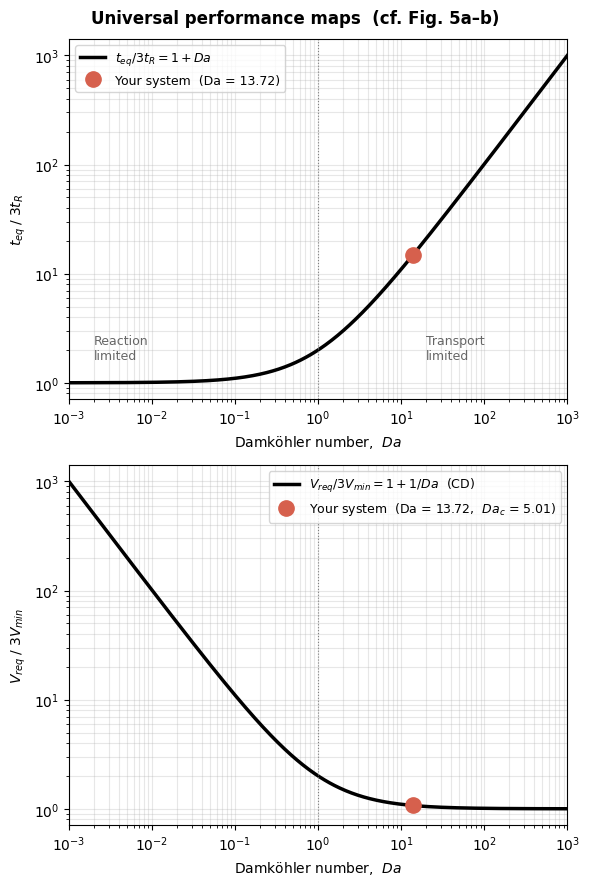

In [149]:
# ============================================================
# FIGURES 5a & 5b — Universal maps with your system as a point
# x-axis: Damköhler number Da
# ============================================================

Da_sweep = np.logspace(-3, 3, 500)

# Analytical curve inside complete delivery (solid)
t_norm_cd  = 1 + Da_sweep                           # teq / 3tR  (Eq. 17)
V_norm_cd  = 1 + 1 / Da_sweep                       # Vreq / 3Vmin  (Eq. 18)

# Your system's normalised position
t_norm_sys = t_eq / (3 * t_R)
V_norm_sys = V_req / (3 * V_min)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))
fig.suptitle('Universal performance maps  (cf. Fig. 5a–b)', fontweight='bold')

# ── (a) Equilibration time ──────────────────────────────────
ax1.loglog(Da_sweep, t_norm_cd, 'k-', lw=2.5, label=r'$t_{eq}/3t_R = 1 + Da$')
ax1.loglog(Da, t_norm_sys, 'o', color='#d6604d', ms=11, zorder=5,
           label=f'Your system  (Da = {Da:.2f})')

ax1.axvline(1, color='gray', lw=0.8, ls=':')
ax1.text(2e-3, 1.65, 'Reaction\nlimited', fontsize=9, color='#666')
ax1.text(2e1,  1.65, 'Transport\nlimited', fontsize=9, color='#666')

ax1.set_xlabel('Damköhler number,  $Da$')
ax1.set_ylabel(r'$t_{eq}\;/\;3t_R$')
ax1.set_xlim([1e-3, 1e3])
ax1.legend(fontsize=9)
ax1.grid(True, which='both', alpha=0.3)

# ── (b) Required volume ─────────────────────────────────────
ax2.loglog(Da_sweep, V_norm_cd, 'k-', lw=2.5, label=r'$V_{req}/3V_{min} = 1+1/Da$  (CD)')

if Q > Q_c:
    V_norm_ocd = (1 + 1/Da_sweep) * (Da_c / Da_sweep)**2
    mask = (Da_sweep >= Da_c * 0.01) & (Da_sweep <= Da_c)
    ax2.loglog(Da_sweep[mask], V_norm_ocd[mask], '--', color='#4dac26', lw=1.8,
               label=f'Outside CD,  $Da_c = {Da_c:.2f}$')

ax2.loglog(Da, V_norm_sys, 'o', color='#d6604d', ms=11, zorder=5,
           label=f'Your system  (Da = {Da:.2f},  $Da_c$ = {Da_c:.2f})')

ax2.axvline(1, color='gray', lw=0.8, ls=':')
ax2.set_xlabel('Damköhler number,  $Da$')
ax2.set_ylabel(r'$V_{req}\;/\;3V_{min}$')
ax2.set_xlim([1e-3, 1e3])

ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

The effect of chaning the flow rate can be tested, similar to Figure 5d and 5e from the main text.

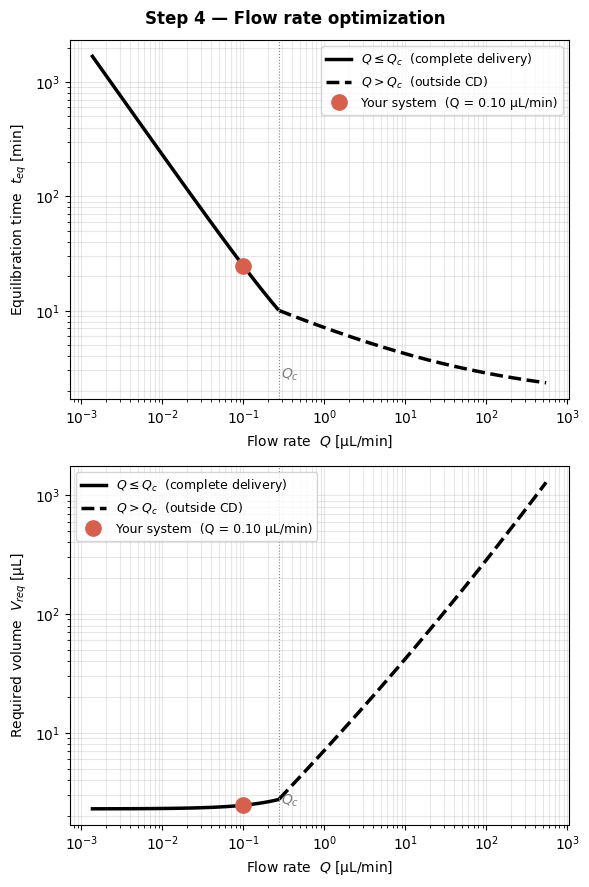

In [150]:
# ============================================================
# STEP 4 — OPTIMIZE: sweep flow rate Q
# ============================================================
import matplotlib.pyplot as plt

Q_arr = np.logspace(np.log10(Q_c * 5e-3), np.log10(Q_c * 2e3), 300)

t_eq_arr, V_req_arr, cd_arr = [], [], []

for Qi in Q_arr:
    if Qi <= Q_c or valid_eps == False:
        km_i = Qi / (W_c * H_c)
        cd_i = True
    else:
        km_i = (D/H_c) * (1.79*lam)**(2/3) * (Qi/(D*W_c))**(1/3)  # always physical
        cd_i = False   # ε < 10 → no depletion penalty, use CD V_req formula

    Da_i    = (k_on * b_m * L_s) / (km_i * H_c)   # always from physical k_m
    t_eq_i  = 3 * (1 + Da_i) * t_R
    V_req_i = 3 * V_min * (1 + 1/Da_i) if cd_i else \
              3 * V_min * (1 + 1/Da_i) * (Da_c/Da_i)**2


    t_eq_arr.append(t_eq_i / 60)       # min
    V_req_arr.append(V_req_i * 1e9)    # µL
    cd_arr.append(cd_i)

t_eq_arr  = np.array(t_eq_arr)
V_req_arr = np.array(V_req_arr)
cd_arr    = np.array(cd_arr)
Q_uL      = Q_arr * 1e9 * 60

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))
fig.suptitle('Step 4 — Flow rate optimization', fontweight='bold')

for ax, y, ylabel in [
    (ax1, t_eq_arr,  'Equilibration time  $t_{eq}$ [min]'),
    (ax2, V_req_arr, 'Required volume  $V_{req}$ [µL]'),
]:
    ax.loglog(Q_uL[cd_arr],   y[cd_arr],  '-',  color='k',        lw=2.5, label='$Q \\leq Q_c$  (complete delivery)')
    ax.loglog(Q_uL[~cd_arr],  y[~cd_arr], '--', color='k',        lw=2.5, label='$Q > Q_c$  (outside CD)')
    ax.axvline(Q_c*1e9*60, color='gray', lw=0.8, ls=':')
    ax.text(Q_c*1e9*60*1.08, ax.get_ylim()[0]*1.5, '$Q_c$', color='gray', fontsize=10)
    y_cur = t_eq/60 if 'time' in ylabel else V_req*1e9
    ax.loglog(Q*1e9*60, y_cur, 'o', color='#d6604d', ms=11, zorder=5,
              label=f'Your system  (Q = {Q*1e9*60:.2f} µL/min)')
    ax.set_xlabel('Flow rate  $Q$ [µL/min]')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()